# Diffusion Distance Based Clustering

Execution notebook using the reusable functions in `ddbc_functions.py`.

# Import

In [1]:
%load_ext autoreload
%autoreload 2

import gc
import os
import pickle
import matplotlib.pyplot as plt
import numpy as np

from ddbc_functions import (
    DDBCConfig,
    big_objects,
    build_column_aggregation_matrix,
    build_interlayer_coupling_matrices,
    build_kNN,
    build_layer_adjacency_matrices,
    build_multilayer_transition_matrix,
    build_row_aggregation_matrix,
    build_distinct_gene_mapping,
    compute_and_save_diffusion_distance,
    compute_average_transition_matrix,
    compute_stationary_layer_weights,
    load_bootstrap_scores,
    load_diffusion_distance,
    load_matrices,
    plot_stationary_layer_weights,
    run_bootstrap_robustness,
    run_clustering,
    select_communities,
    stationary_distribution,
)

# Configuration

In [2]:
DISEASE = input("Disease: ")

config = DDBCConfig(
    disease=DISEASE,
    average_t=[2, 4, 6, 8],
    interlayer_transition_prob=0.35,
    num_neighbors=400,
    resolution=1.3,
    size_cap=100,
    score_cap=0,
    n_boots=1000,
    check_every=50,
    tol=0.01,
    patience=2,
    sampling_pct=0.8,
    leiden_seed=42,
)

# Building Multilayer Transition Matrix

In [3]:
os.makedirs(config.output_directory, exist_ok=True)

matrices = load_matrices(config)
DGIDB_adjacency_matrix, MSIGDB_adjacency_matrix = (
    build_layer_adjacency_matrices(matrices)
)

[1.0000001  0.9999999  1.         1.         1.         1.0000001
 1.         0.9999999  1.         0.99999994 1.         1.
 1.         0.99999994 1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         0.99999994 0.99999994 0.99999994 1.         1.
 0.99999994 1.0000001  0.99999994 1.         0.9999999  1.
 1.         1.         0.99999994 1.         1.         1.
 0.99999994 1.0000001  0.99999994 1.         1.         0.99999994
 1.         1.         1.         0.9999999  0.99999994 1.
 1.         1.         1.         1.         1.         1.
 1.         1.         0.9999999  1.         1.0000001  0.9999998
 0.99999994 1.0000001  1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 0.9999999  1.         1.0000001  1.         1.         1.
 1.         0.99999994 1.         1.         0.99999994 1.
 1.         1.         0.99999994 0.99999994 1.         1.
 1.         1.         1.         

## Coupling matrices and distinct gene indices

In [4]:
coupling = build_interlayer_coupling_matrices(
    DGIDB_adjacency_matrix,
    MSIGDB_adjacency_matrix,
    config,
)

gene_to_index_distinct = build_distinct_gene_mapping(coupling, config)

Gene 360158 not found in MSIGDB mapping.
Gene 11 not found in MSIGDB mapping.
Gene 100302144 not found in MSIGDB mapping.
Gene 100302251 not found in MSIGDB mapping.
Gene 79529 not found in MSIGDB mapping.
Gene 236 not found in MSIGDB mapping.
Gene 652991 not found in MSIGDB mapping.
Gene 267012 not found in MSIGDB mapping.
Gene 693167 not found in MSIGDB mapping.
Gene 927 not found in MSIGDB mapping.
0.9721448467966574 of DGIDB genes have a match in MSIGDB
Mappings saved to ../output/BIPOLAR/dgidb_to_msigdb_indices_dict.json
Mappings saved to ../output/BIPOLAR/gene_to_index_distinct.json


## Construct the multilayer transition matrix

In [5]:
P = build_multilayer_transition_matrix(
    DGIDB_adjacency_matrix,
    MSIGDB_adjacency_matrix,
    coupling,
)
num_genes = P.shape[0]

del DGIDB_adjacency_matrix, MSIGDB_adjacency_matrix
for _ in range(3):
    gc.collect()

[1.00000001 0.99999992 1.         ... 1.         1.         1.        ]
Every row sums to 1? True


## Stationary distribution

In [6]:
pi = stationary_distribution(
    P,
    tol=config.stationary_tol,
    maxit=config.stationary_maxit,
    seed=config.stationary_seed,
)
pi

array([4.24700283e-08, 4.19749743e-04, 8.57273814e-04, ...,
       3.09682860e-10, 3.25358442e-10, 3.19837611e-10])

# Aggregation

## Column aggregation

In [7]:
A_c = build_column_aggregation_matrix(
    P,
    coupling,
    gene_to_index_distinct,
)

## Preparing weights

Average stationary probability for DGIDB genes: 0.00019742700999143188
Average stationary probability for MSIGDB genes: 4.226940100145926e-05
Ratio of averages (DGIDB/MSIGDB): 4.6706838827599215


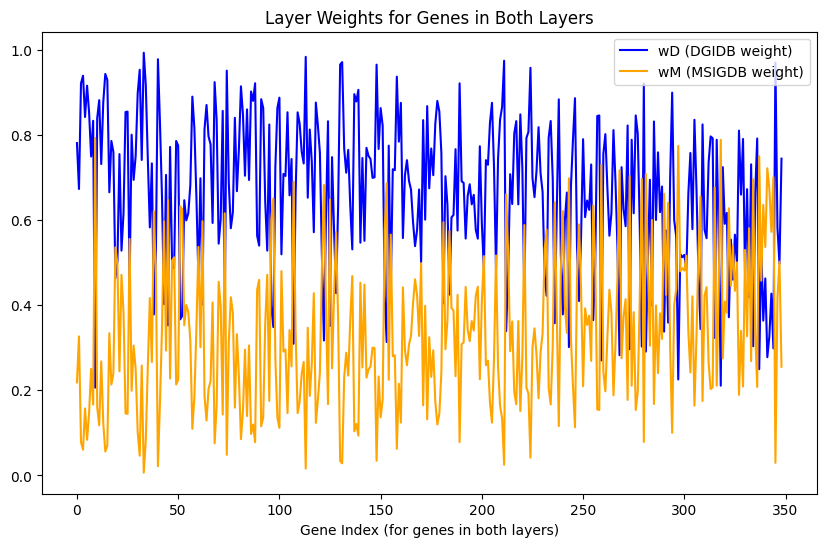

In [8]:
wD_list, wM_list = compute_stationary_layer_weights(pi, coupling)
plot_stationary_layer_weights(wD_list, wM_list, config)

## Row aggregation

In [9]:
A_r, wD_list2, wM_list2 = build_row_aggregation_matrix(
    P,
    pi,
    coupling,
    gene_to_index_distinct,
)

assert wD_list == wD_list2 and wM_list == wM_list2

# Matrix-Free Method

In [10]:
P_t_agg_avg = compute_average_transition_matrix(
    P,
    A_r,
    A_c,
    config.average_t,
)

big_objects()

100%|██████████| 21991/21991 [7:11:01<00:00,  1.18s/it]  

Variable                       Type                       Size (MB)
----------------------------------------------------------------------
P_t_agg_avg                    ndarray                      3689.61
P                              csr_matrix                   1255.85
gene_to_index_distinct         dict                            1.25


In [11]:
D_avg = compute_and_save_diffusion_distance(P_t_agg_avg, config)

In [12]:
del P_t_agg_avg
gc.collect()

4152

# Clustering Methods

## Constructing kNN

In [13]:
if "D_avg" not in locals():
    D_avg = load_diffusion_distance(config)

kNN_adjacency_matrix, kNN_graph = build_kNN(
    D_avg,
    k=config.num_neighbors,
    sym_method="average",
)
kNN_adjacency_matrix.data.mean()

0.4624166000004564

In [14]:
with open(f"{config.output_directory}/result_graph.pkl", "wb") as file:
    pickle.dump(kNN_graph, file)

# Leiden Clustering

In [15]:
labels, score, communities = run_clustering(
    kNN_adjacency_matrix,
    config,
)

Wrote: ..\output\BIPOLAR\leiden_report.pdf
[[30, 43, 76, 80, 94, 110, 137, 140, 154, 156, 198, 202, 215, 243, 270, 319, 320, 322, 324, 328, 329, 338, 340, 351, 354, 361, 382, 417, 426, 452, 457, 495, 538, 543, 550, 552, 582, 609, 706, 708, 732, 779, 785, 830, 831, 857, 858, 861, 862, 870, 873, 874, 875, 877, 883, 889, 890, 917, 959, 983, 991, 1006, 1016, 1036, 1037, 1052, 1091, 1114, 1116, 1164, 1205, 1207, 1208, 1240, 1267, 1268, 1269, 1270, 1271, 1272, 1273, 1275, 1293, 1319, 1325, 1358, 1374, 1389, 1390, 1435, 1447, 1457, 1473, 1486, 1502, 1515, 1523, 1524, 1525, 1526, 1528, 1551, 1591, 1600, 1637, 1659, 1711, 1712, 1717, 1720, 1721, 1722, 1723, 1724, 1725, 1726, 1727, 1728, 1736, 1764, 1765, 1766, 1767, 1768, 1770, 1771, 1772, 1774, 1792, 1793, 1795, 1809, 1828, 1836, 1860, 1862, 1883, 1935, 2009, 2074, 2075, 2076, 2077, 2120, 2145, 2146, 2148, 2166, 2196, 2223, 2239, 2240, 2246, 2278, 2289, 2331, 2333, 2352, 2374, 2375, 2492, 2639, 2682, 2686, 2745, 2781, 2788, 2803, 2825, 2839, 2

# Select Communities

In [16]:
communities_selected = select_communities(kNN_graph, communities, config)
top_m = len(communities_selected)
print(top_m)

1008 3332 0.3025210084033613
1031 3148 0.32750952986022874
949 2882 0.3292852185981957
1162 2789 0.4166367873789889
949 2463 0.3853024766544864
837 1938 0.43188854489164086
502 1396 0.35959885386819485
565 1377 0.4103122730573711
556 1363 0.40792369772560527
340 476 0.7142857142857143
299 408 0.7328431372549019
119 270 0.44074074074074077
12


# Create graph folder

In [17]:
os.makedirs(config.graph_directory, exist_ok=True)

# Robustness Analysis

In [ ]:
big_objects()
ari_scores = run_bootstrap_robustness(kNN_adjacency_matrix, config)

In [ ]:
if "ari_scores" not in locals():
    ari_scores = load_bootstrap_scores(config)

median_ari = np.median(ari_scores)
mean_ari = np.mean(ari_scores)
std_ari = np.std(ari_scores)
print("Median ARI:", median_ari)
print("Mean ARI:", mean_ari)
print("STD of ARI:", std_ari)

In [ ]:
font_size = 20
tick_font_size = 16
plt.rcParams.update(
    {
        "font.size": font_size,
        "axes.titlesize": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": tick_font_size,
        "ytick.labelsize": tick_font_size,
        "legend.fontsize": font_size,
        "figure.titlesize": font_size,
        "legend.loc": "best",
    }
)

plt.figure(figsize=(6, 4))
plt.hist(ari_scores, bins=15, edgecolor="black")
plt.axvline(
    median_ari,
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_ari:.3f}",
)
plt.xlabel("Adjusted Rand Index (ARI)")
plt.ylabel("Sample Count")
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig(
    f"{config.graph_directory}/ari_stability_plot.png",
    dpi=300,
)
plt.show()